Step 1 :- Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

Step 2 :- Load Dataset

In [ ]:
df=pd.read_csv("Crop_recommendation.csv")
df.head() # It gives the first five rows of the dataset. It helps to get an initial understanding of the data and its structure.

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Step :- Data Exploration
#In this section we will explore data

In [ ]:
df.shape

(2200, 8)

In [ ]:
df.dtypes
# It gives the data types of each column in the dataset. This information helps to understand the nature of the data and how it can be processed for analysis and modeling.

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [ ]:
df.describe()
# It gives the statistical summary of the dataset. It includes count, mean, standard deviation, minimum, 25th percentile, 50th percentile (median), 75th percentile, and maximum values for each numerical column in the dataset. This information helps to understand the distribution and central tendency of the data.

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
 df.duplicated().sum()
#It gives number of duplicate elements in the datset. in this dataset duplicate value is zero which means their is no duplicate value

np.int64(0)

In [ ]:
df['label'].unique()
# It gives the unique values in the 'label' column, which represents the different types of crops in the dataset. This information helps to understand the variety of crops that are being recommended based on the features in the dataset.

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

Step 3 :- EDA-Visualizations
# In this section we will explore data and takes insites from visualising the data

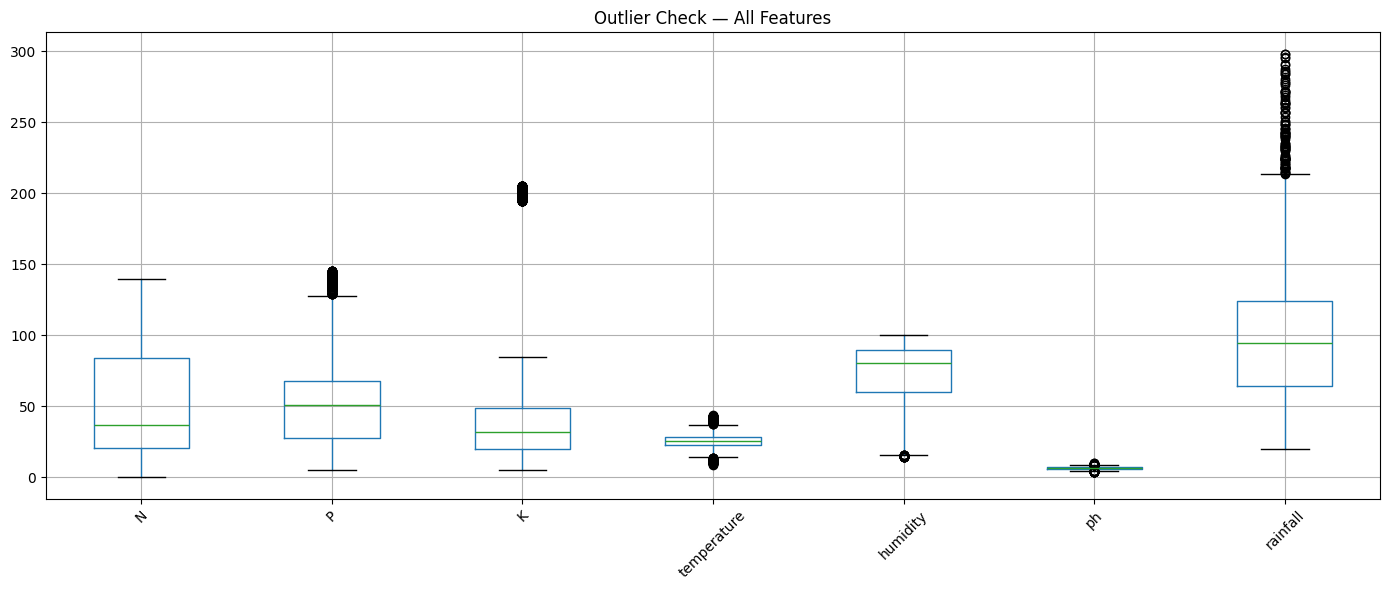

In [10]:
plt.figure(figsize=(14,6))
df.drop('label', axis=1).boxplot()
plt.title('Outlier Check — All Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# The boxplot is a graphical representation of the distribution of the data and helps to identify outliers. In this case, the boxplot is created for all features except the 'label' column. Each box represents the interquartile range (IQR) of the data, with the line inside the box representing the median. The whiskers extend to 1.5 times the IQR, and any points outside this range are considered outliers. This visualization helps to check for outliers in the dataset, which can affect the performance of machine learning models.

Here, The boxplot shows that Rainfall has the most outliers going upto 300mm which is natural as rainfall varies in real world. K has one high outlier near 200 and N, P have few acceptable outliers. Temperature, Humidity and pH values are very clean with almost no outliers. Overall the dataset is clean and ready for ML model training.

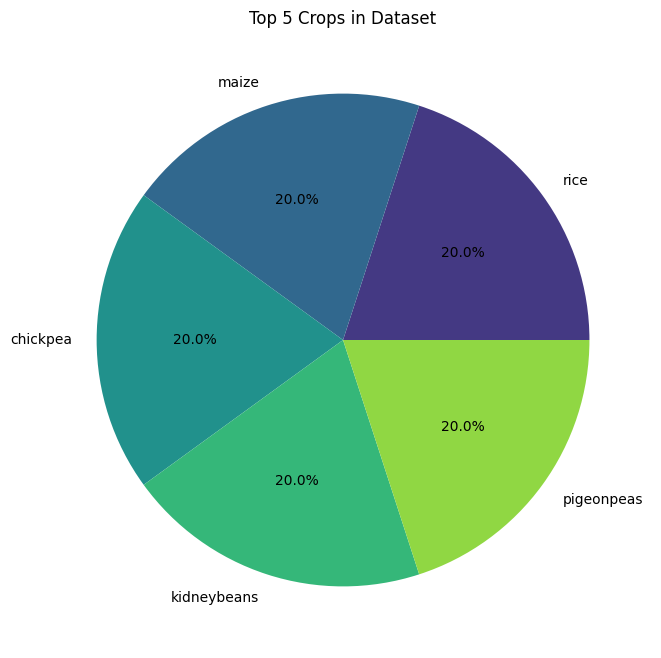

In [11]:
plt.figure(figsize=(8,8))
top5 = df['label'].value_counts().head(5)
plt.pie(top5.values, 
        labels=top5.index, 
        autopct='%1.1f%%',
        colors=sns.color_palette('viridis', 5))
plt.title('Top 5 Crops in Dataset')
plt.show()

This will show the percentage of top 5 crops

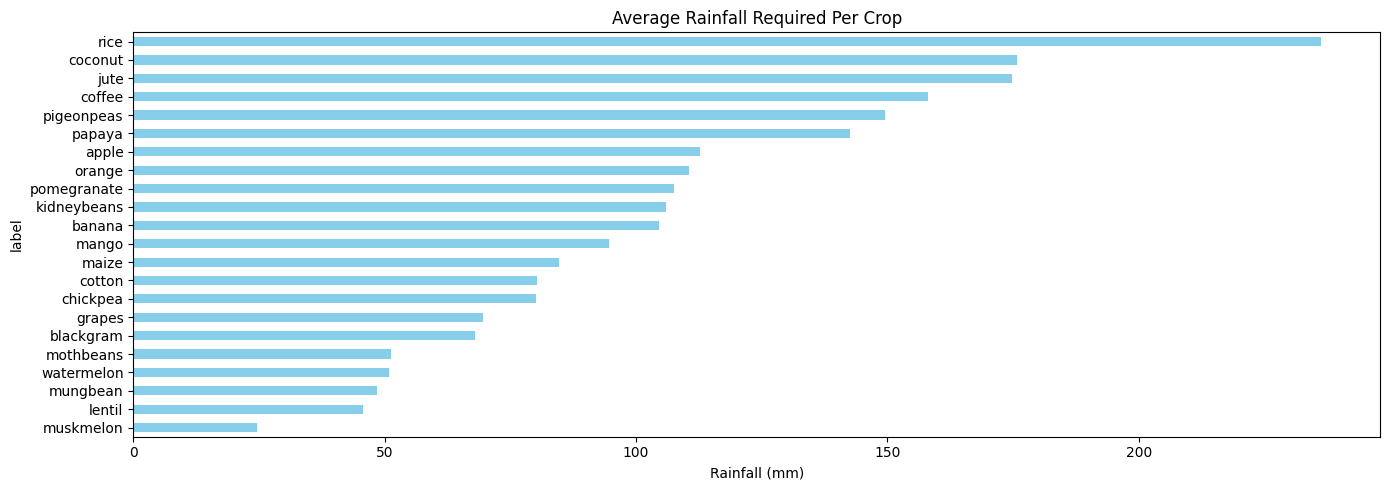

In [12]:
plt.figure(figsize=(14,5))
df.groupby('label')['rainfall'].mean().sort_values()\
  .plot(kind='barh', color='skyblue')
plt.title('Average Rainfall Required Per Crop')
plt.xlabel('Rainfall (mm)')
plt.tight_layout()
plt.show()

 In this graph will show how much water is required for crops here rice requires good amout of water to grow and least is muskmelon it require less water to grow

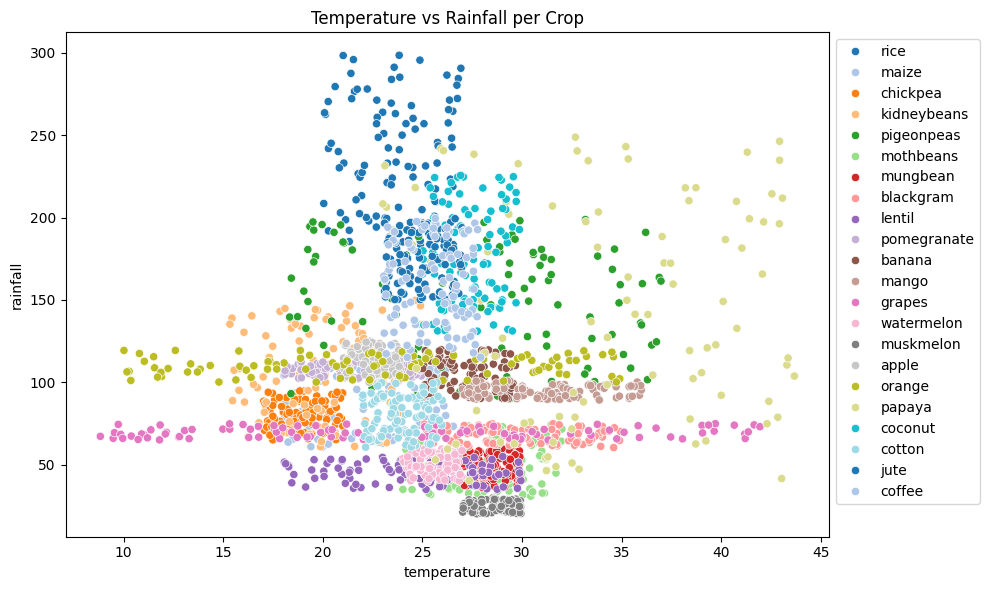

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='temperature', 
                y='rainfall', 
                hue='label', 
                data=df,
                palette='tab20')
plt.title('Temperature vs Rainfall per Crop')
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

this graph will show the relation ship between water and temprature for each crop

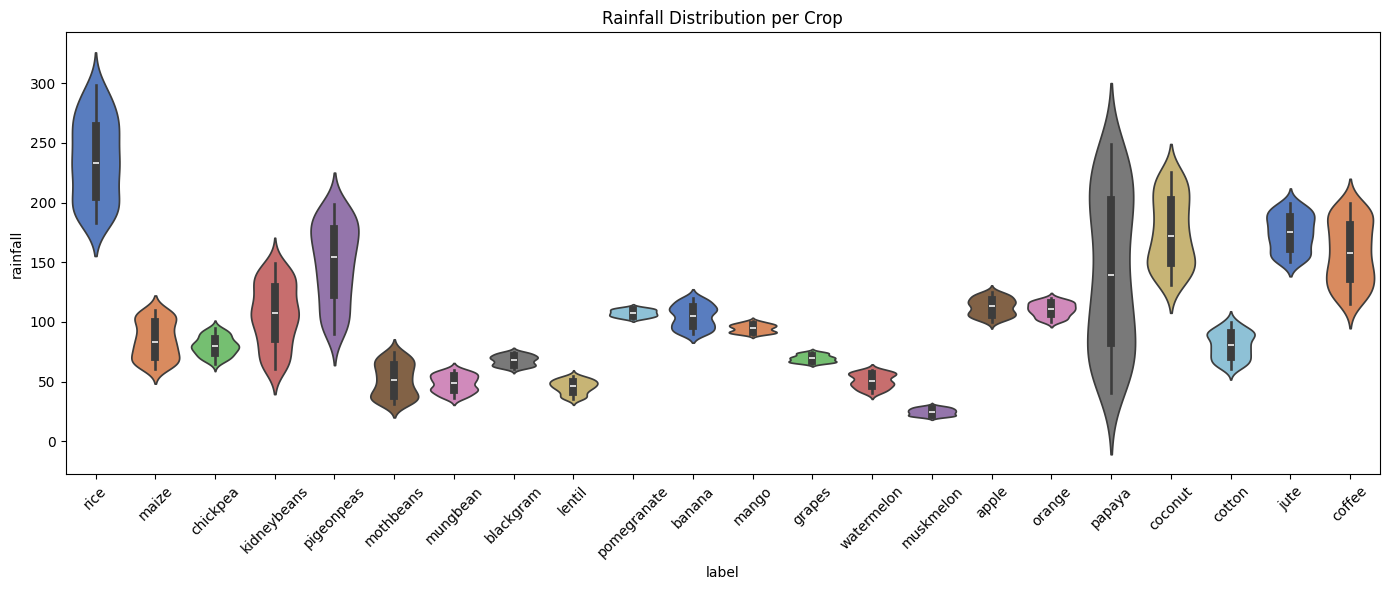

In [14]:
plt.figure(figsize=(14,6))
sns.violinplot(x='label', y='rainfall',
               data=df, palette='muted')
plt.title('Rainfall Distribution per Crop')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

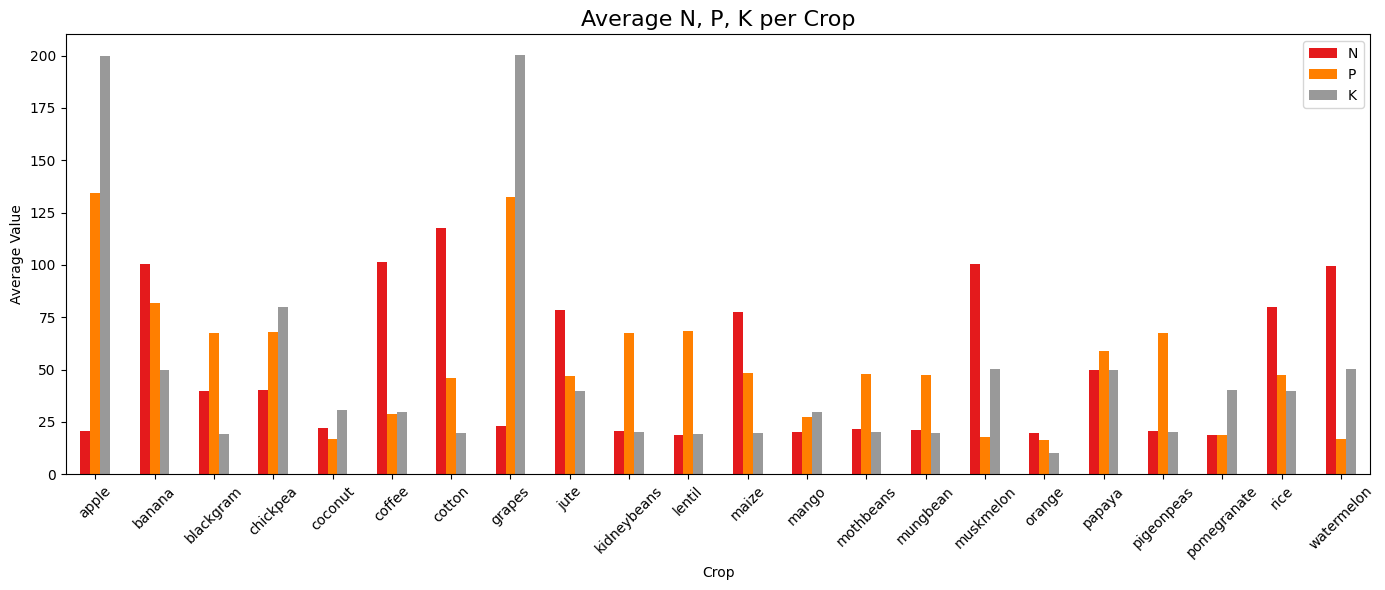

In [15]:
plt.figure(figsize=(9,5))
npk = df.groupby('label')[['N','P','K']].mean()
npk.plot(kind='bar', figsize=(14,6), colormap='Set1')
plt.title('Average N, P, K per Crop', fontsize=16)
plt.xlabel('Crop')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


this graph will show the average nitrogen posphorous potassium and required ton grow crops

Step 4 :- ML Model Building

In [16]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


This code separates the dataset into input features X which contains N, P, K, temperature, humidity, pH and rainfall and output y which contains crop name. Then data is split into 80% for training and 20% for testing. Finally Random Forest model is trained on the training data.

Step 5 :- Model Evaluation

In [17]:
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 99.32%


This code tests the trained model on 20% test data and calculates how many predictions were correct. The accuracy score is then printed as a percentage. Higher the percentage better the model.

Step 6 :- Crop Prediction

In [ ]:
N, P, K    = 30, 20, 20  
rain       = 200           
tmp        = 45          

prediction = model.predict([[N,P,K,tmp,70,6.5,rain]])[0]
proba      = model.predict_proba([[N,P,K,tmp,70,6.5,rain]])[0]
top3       = model.classes_[proba.argsort()[-3:][::-1]]
conf       = sorted(proba)[-3:][::-1]*100

print(f"Best Crop : {top3[0].upper()} ({conf[0]:.1f}%)")
print(f" 2nd Choice: {top3[1].upper()} ({conf[1]:.1f}%)")
print(f"3rd Choice: {top3[2].upper()} ({conf[2]:.1f}%)")

Best Crop : PIGEONPEAS (0.3%)
 2nd Choice: MANGO (0.3%)
3rd Choice: ORANGE (0.2%)


you can change the values according to your condition of soil


N, P, K = 90, 55, 45  → High Fertility
N, P, K = 60, 40, 35  → Medium Fertility
N, P, K = 30, 20, 20  → Low Fertility

rain = 80   → Low Rainfall
rain = 150  → Medium Rainfall
rain = 250  → High Rainfall

tmp = 15  → Cold
tmp = 25  → Normal
tmp = 35  → Hot